In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nlp-a3-dataset/shakespear_dev.txt
/kaggle/input/nlp-a3-dataset/shakespear_train.txt


Using device: cuda
Loading and preprocessing data...
Vocabulary size: 65
Vocabulary: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
Training data tokens: 938743
Validation data tokens: 113449
Model initialized.
Number of parameters: 10.75 M
Starting training for 20000 iterations...
Step 0: Train Loss 4.1986, Val Loss 4.1985, Time: 51.31s
New best validation loss: 4.1985. Saving model to task1_transformer_shakespeare_v2.pth...
Sample generation:
---

?qf;xbDkRZkNdc.wf,ZT,OLlT,ebtK
b:iPjCkMBbzB$3:.aSvgO-33SM:d?gLTauhX:YVnJthheNuwqcB,xv.tbaF dXlaDwaAe
---
Iteration 100/20000, Loss: 2.3801
Iteration 200/20000, Loss: 2.2820
Iteration 300/20000, Loss: 2.1629
Iteration 400/20000, Loss: 1.9878
Iteration 500/20000, Loss: 1.8574
Iteration 600/20000, Loss: 1.7615
Iteration 700/20000, Loss: 1.6597
Iteration 800/20000, Loss: 1.6187
Iteration 900/20000, Loss: 1.6090
Step 1000: Train Loss 1.4456, Val Loss 1.6041, Time: 540.77s
New best validation loss: 1.6041. Saving model to task1

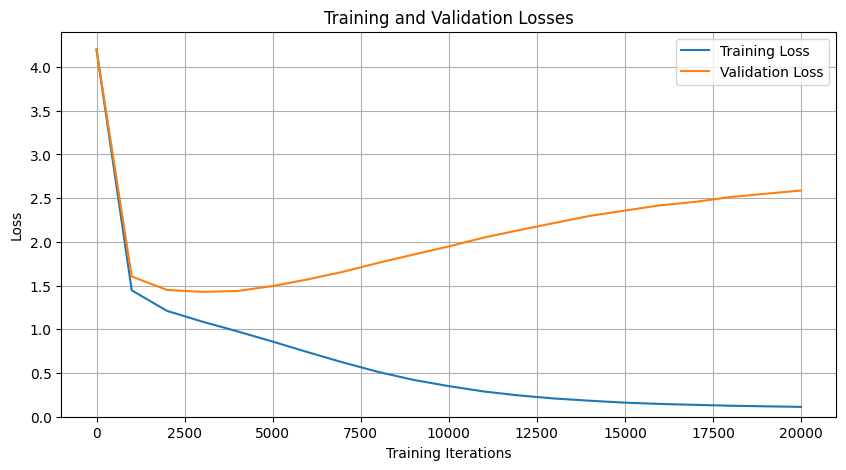

In [2]:
# Add imports here
import torch
import torch.nn as nn
from torch.nn import functional as F
import math
import time
import os
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
from argparse import Namespace as SimpleNamespace # Keep SimpleNamespace

# --- Configuration ---
# Kaggle Environment Check (adjust device if necessary)
IS_KAGGLE = os.path.exists('/kaggle/input')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Hyperparameters (Adjusted for longer training and regularization)
BATCH_SIZE = 64        # How many independent sequences will we process in parallel?
BLOCK_SIZE = 256       # What is the maximum context length for predictions? (MAX_LEN)
MAX_ITERS = 20000      # Increased training iterations ***** MODIFIED *****
EVAL_INTERVAL = 1000   # Evaluate less frequently but still regularly ***** MODIFIED *****
LEARNING_RATE = 3e-4   # Learning rate (AdamW default is 1e-3, 3e-4 is common for transformers)
EVAL_ITERS = 200       # Number of iterations for estimating validation loss
N_EMBD = 384           # Embedding dimension
N_HEAD = 6             # Number of attention heads
N_LAYER = 6            # Number of transformer blocks
DROPOUT = 0.2          # Increased dropout rate ***** MODIFIED *****
WEIGHT_DECAY = 0.1     # Added weight decay for regularization ***** NEW *****

# Data Paths (Adjust if your Kaggle dataset path is different)
TRAIN_FILE = '/kaggle/input/nlp-a3-dataset/shakespear_train.txt' if IS_KAGGLE else 'shakespear_train.txt'
DEV_FILE = '/kaggle/input/nlp-a3-dataset/shakespear_dev.txt' if IS_KAGGLE else 'shakespear_dev.txt'
TEST_FILE = 'shakespear_test.txt' # Provided during demo
MODEL_SAVE_PATH = 'task1_transformer_shakespeare_v2.pth' # Save to a new file

# Ensure N_EMBD is divisible by N_HEAD
assert N_EMBD % N_HEAD == 0

# Seed for reproducibility
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)

# --- Data Loading and Preprocessing ---

def load_and_preprocess_data(train_file, dev_file):
    """Loads data, creates vocabulary, and tokenizes."""
    print("Loading and preprocessing data...")
    try:
        # Use utf-8-sig to automatically handle/skip the BOM if present
        with open(train_file, "r", encoding='utf-8-sig') as f: # Use utf-8-sig
            text_train = f.read()
        with open(dev_file, "r", encoding='utf-8-sig') as f: # Use utf-8-sig
            text_dev = f.read()
    except FileNotFoundError as e:
        print(f"Error loading data files: {e}")
        print("Please ensure the file paths are correct:")
        print(f"Train: {train_file}")
        print(f"Dev: {dev_file}")
        raise

    # Create character vocabulary from training data
    chars = sorted(list(set(text_train)))
    vocab_size = len(chars)
    print(f"Vocabulary size: {vocab_size}")
    print(f"Vocabulary: {''.join(chars)}")

    # Create character-to-integer mapping (tokenizer)
    char_to_ix = {ch: i for i, ch in enumerate(chars)}
    # Create integer-to-character mapping (inverse tokenizer)
    ix_to_char = {i: ch for i, ch in enumerate(chars)}

    # Tokenize the datasets
    data_train = torch.tensor(encode(text_train, char_to_ix), dtype=torch.long)
    data_val = torch.tensor(encode(text_dev, char_to_ix), dtype=torch.long)

    print(f"Training data tokens: {len(data_train)}")
    print(f"Validation data tokens: {len(data_val)}")
    return data_train, data_val, char_to_ix, ix_to_char, vocab_size

def encode(s, tokenizer):
    """Encode string to list of integers."""
    return [tokenizer[c] for c in s]

def decode(l, inv_tokenizer):
    """Decode list of integers to string."""
    return ''.join([inv_tokenizer[i] for i in l])

def get_batch(split, data_train, data_val):
    """Generate a small batch of data of inputs x and targets y."""
    data = data_train if split == 'train' else data_val
    ix = torch.randint(len(data) - BLOCK_SIZE, (BATCH_SIZE,))
    x = torch.stack([data[i:i+BLOCK_SIZE] for i in ix])
    y = torch.stack([data[i+1:i+BLOCK_SIZE+1] for i in ix])
    x, y = x.to(DEVICE), y.to(DEVICE)
    return x, y

# --- Transformer Model Components ---

class CausalSelfAttention(nn.Module):
    """
    A single head of self-attention with causal masking.
    """
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.head_dim = config.n_embd // config.n_head

        # Key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=False)
        # Output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=False)
        # Regularization
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)

        # Causal mask
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                     .view(1, 1, config.block_size, config.block_size))
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout # Store dropout rate from config

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # Calculate query, key, values for all heads
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2) # (B, nh, T, hs)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2) # (B, nh, T, hs)

        # Scaled Dot-Product Attention
        att = (q @ k.transpose(-2, -1)) * (k.size(-1)**-0.5) # Scale
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf')) # Apply mask
        att = F.softmax(att, dim=-1) # Normalize
        att = self.attn_dropout(att)
        y = att @ v # Weighted aggregation: (B, nh, T, T) @ (B, nh, T, hs) -> (B, nh, T, hs)

        # Re-assemble heads
        y = y.transpose(1, 2).contiguous().view(B, T, C)

        # Output projection
        y = self.resid_dropout(self.c_proj(y))
        return y

class MultiHeadAttention(nn.Module):
    """ Multi-head attention module. """
    def __init__(self, config):
        super().__init__()
        self.attention = CausalSelfAttention(config)

    def forward(self, x):
        return self.attention(x)

class FeedForward(nn.Module):
    """ Feed-forward network """
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd, bias=False),
            nn.GELU(),
            nn.Linear(4 * config.n_embd, config.n_embd, bias=False),
            nn.Dropout(config.dropout), # Use dropout from config
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = MultiHeadAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.ffn = FeedForward(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x)) # Attention + Residual
        x = x + self.ffn(self.ln_2(x))  # FFN + Residual
        return x

class TransformerLM(nn.Module):
    """ The full Transformer Language Model """
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd), # Token embeddings
            wpe = nn.Embedding(config.block_size, config.n_embd), # Positional embeddings
            drop = nn.Dropout(config.dropout), # Use dropout from config
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]), # Transformer blocks
            ln_f = nn.LayerNorm(config.n_embd), # Final layer norm
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False) # Output head

        # Weight tying
        self.transformer.wte.weight = self.lm_head.weight

        # Init weights
        self.apply(self._init_weights)

        # Special init for residual projections
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02/math.sqrt(2 * config.n_layer))

        print("Model initialized.")
        print(f"Number of parameters: {sum(p.numel() for p in self.parameters())/1e6:.2f} M")

    def _init_weights(self, module):
        """ Initialize weights """
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            torch.nn.init.zeros_(module.bias)
            torch.nn.init.ones_(module.weight)

    def forward(self, idx, targets=None):
        B, T = idx.size()
        assert T <= self.config.block_size, f"Sequence length {T} exceeds block size {self.config.block_size}"
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device).unsqueeze(0) # shape (1, T)

        # Forward pass
        tok_emb = self.transformer.wte(idx) # (B, T, n_embd)
        pos_emb = self.transformer.wpe(pos) # (1, T, n_embd)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x) # (B, T, n_embd)

        if targets is not None:
            logits = self.lm_head(x) # (B, T, vocab_size)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        else:
            # Inference: only compute logits for the last token
            logits = self.lm_head(x[:, [-1], :]) # (B, 1, vocab_size)
            loss = None

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """ Generate sequence continuation """
        idx = idx.to(DEVICE)
        for _ in range(max_new_tokens):
            # Crop context if needed
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            # Get predictions
            logits, _ = self(idx_cond)
            # Focus on the last time step, apply temperature
            logits = logits[:, -1, :] / temperature # (B, C)
            # Optional top-k sampling
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            # Get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # Sample next token
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # Append to sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

# --- Evaluation Functions ---

@torch.no_grad()
def estimate_loss(model, data_train, data_val, config): # Pass config
    """ Estimates loss on train and val sets """
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(config.eval_iters) # Use config.eval_iters
        for k in range(config.eval_iters): # Use config.eval_iters
            X, Y = get_batch(split, data_train, data_val)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

@torch.no_grad()
def calculate_perplexity(model, data_tensor, config):
    """ Calculates perplexity on a given dataset tensor. """
    print(f"Calculating perplexity on data with {len(data_tensor)} tokens...")
    model.eval()
    total_loss = 0
    total_tokens = 0

    indices = range(0, data_tensor.size(0) - 1, config.block_size)
    it = tqdm(indices, desc="Perplexity calculation") if len(indices) > 100 else indices

    for i in it:
        end_idx = min(i + config.block_size, data_tensor.size(0) - 1)
        batch_x = data_tensor[i:end_idx].unsqueeze(0).to(DEVICE)
        batch_y = data_tensor[i+1:end_idx+1].unsqueeze(0).to(DEVICE)

        if batch_x.size(1) == 0 or batch_y.size(1) == 0:
             continue

        logits, loss = model(batch_x, batch_y)
        total_loss += loss.item() * batch_y.numel()
        total_tokens += batch_y.numel()

    model.train()
    if total_tokens == 0:
        print("Warning: No tokens processed for perplexity calculation.")
        return float('inf')

    avg_loss = total_loss / total_tokens
    perplexity = math.exp(avg_loss)
    print(f"Average Loss: {avg_loss:.4f}, Total Tokens: {total_tokens}")
    return perplexity

# --- Training Loop ---

def train_model(model, optimizer, data_train, data_val, config, char_to_ix, ix_to_char):
    """ Implements the training loop. """
    train_losses = []
    val_losses = []
    tracked_steps = []
    best_val_loss = float('inf')
    start_time = time.time()

    print(f"Starting training for {config.max_iters} iterations...")
    for iter_num in range(config.max_iters):

        # Evaluate periodically
        if iter_num % config.eval_interval == 0 or iter_num == config.max_iters - 1:
            losses = estimate_loss(model, data_train, data_val, config) # Pass config
            current_time = time.time()
            elapsed_time = current_time - start_time
            print(f"Step {iter_num}: Train Loss {losses['train']:.4f}, Val Loss {losses['val']:.4f}, Time: {elapsed_time:.2f}s")

            val_loss = losses['val']
            val_losses.append(val_loss)
            train_losses.append(losses['train'])
            tracked_steps.append(iter_num)

            # Save best model
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                print(f"New best validation loss: {best_val_loss:.4f}. Saving model to {MODEL_SAVE_PATH}...")
                torch.save(model.state_dict(), MODEL_SAVE_PATH)

            # Generate sample text
            model.eval()
            context = torch.zeros((1, 1), dtype=torch.long, device=DEVICE)
            start_char = '\n'
            if start_char in char_to_ix:
                 context = torch.tensor([[char_to_ix[start_char]]], dtype=torch.long, device=DEVICE)

            generated_indices = model.generate(context, max_new_tokens=100, temperature=0.7)[0].tolist()
            generated_text = decode(generated_indices, ix_to_char)
            print(f"Sample generation:\n---\n{generated_text}\n---")
            model.train()

        # Training step
        xb, yb = get_batch('train', data_train, data_val)
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Gradient clipping
        optimizer.step()

        # Print progress
        if iter_num % 100 == 0 and iter_num % config.eval_interval != 0: # Avoid double printing at eval interval
             print(f"Iteration {iter_num}/{config.max_iters}, Loss: {loss.item():.4f}")

    print("Training finished.")
    total_training_time = time.time() - start_time
    print(f"Total Training Time: {total_training_time:.2f} seconds")
    return train_losses, val_losses, tracked_steps

# --- Inference Function ---

def inference(model_path, test_file, char_to_ix, ix_to_char, config, gen_tokens=100, temperature=0.6):
    """ Loads model, reads test file, generates text, calculates perplexity. """
    print("\n--- Starting Inference ---")
    # Initialize model architecture - IMPORTANT: use the same config as training
    model = TransformerLM(config)
    print(f"Loading model weights from {model_path}...")
    try:
        # Use weights_only=True for security unless you trust the source implicitly
        model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
        model.to(DEVICE)
        model.eval()
        print("Model loaded successfully.")
    except FileNotFoundError:
        print(f"Error: Model file not found at {model_path}")
        return [], float('inf')
    except Exception as e:
        print(f"Error loading model state dict: {e}")
        # Common issue: Mismatch between saved model architecture and current config
        print("Ensure the loaded model's hyperparameters (N_LAYER, N_HEAD, N_EMBD, etc.) match the current config.")
        return [], float('inf')

    # --- Perplexity Calculation on Test Set ---
    test_perplexity = float('inf')
    try:
        print(f"Reading test file: {test_file}")
        # Use utf-8-sig for consistency
        with open(test_file, "r", encoding='utf-8-sig') as f:
            text_test = f.read()
        data_test = torch.tensor(encode(text_test, char_to_ix), dtype=torch.long)
        print(f"Test data loaded: {len(data_test)} tokens.")
        if len(data_test) < 2: # Need at least 2 tokens for one prediction
             print("Warning: Test data too short for perplexity calculation.")
        elif len(data_test) < config.block_size:
             print(f"Warning: Test data ({len(data_test)} tokens) is shorter than block size ({config.block_size}). Perplexity calculated on limited context.")
             test_perplexity = calculate_perplexity(model, data_test, config)
        else:
             test_perplexity = calculate_perplexity(model, data_test, config)

        if test_perplexity != float('inf'):
            print(f"Test Perplexity: {test_perplexity:.4f}")

    except FileNotFoundError:
        print(f"Error: Test file not found at {test_file}. Skipping perplexity calculation.")
    except KeyError as e:
         print(f"Error: Character '{e}' in test file not found in vocabulary. Ensure test data uses only chars from training.")
         print("Skipping perplexity calculation.")
    except Exception as e:
        print(f"Error during test perplexity calculation: {e}")

    # --- Text Generation from Test File Contexts ---
    generated_texts = []
    try:
        with open(test_file, "r", encoding='utf-8-sig') as f: # Use utf-8-sig
            test_lines = f.readlines()

        print(f"\nGenerating text for contexts from {test_file}...")
        for line in test_lines[:5]: # Generate for the first few lines
            context_str = line.strip()
            if not context_str: continue

            print(f"\nContext: {context_str}")
            # Limit context length to avoid exceeding block size during generation
            context_str_input = context_str
            if len(context_str_input) > config.block_size - gen_tokens - 1:
                print(f"(Context truncated for generation input from {len(context_str_input)} chars)")
                context_str_input = context_str_input[-(config.block_size - gen_tokens -1):]


            # Check for unknown characters before encoding
            valid_context = True
            for char in context_str_input:
                if char not in char_to_ix:
                    print(f"Warning: Character '{char}' in context not in vocabulary. Skipping this line for generation.")
                    valid_context = False
                    break
            if not valid_context:
                continue

            context_tokens = encode(context_str_input, char_to_ix)
            context_tensor = torch.tensor([context_tokens], dtype=torch.long, device=DEVICE)

            generated_indices = model.generate(context_tensor,
                                               max_new_tokens=gen_tokens,
                                               temperature=temperature)[0].tolist()

            # Decode only the generated part
            generated_part = decode(generated_indices[len(context_tokens):], ix_to_char)
            print(f"Generated: {generated_part}")
            generated_texts.append({
                "context": context_str, # Store original context
                "generated": generated_part
            })

    except FileNotFoundError:
         print(f"Error: Test file not found at {test_file}. Skipping generation.")
    except KeyError as e:
         print(f"Error: Character '{e}' in test file context not found in vocabulary.")
    except Exception as e:
        print(f"Error during text generation: {e}")

    return generated_texts, test_perplexity

# --- Main Execution Block ---

def main():
    # --- Setup ---
    # Load data and create vocabulary
    data_train, data_val, char_to_ix, ix_to_char, vocab_size = load_and_preprocess_data(TRAIN_FILE, DEV_FILE)

    # Define Model Configuration using global hyperparameters
    # Passed to model, training loop, and inference
    config = SimpleNamespace(
        block_size=BLOCK_SIZE,
        vocab_size=vocab_size,
        n_layer=N_LAYER,
        n_head=N_HEAD,
        n_embd=N_EMBD,
        dropout=DROPOUT,        # Use updated DROPOUT
        max_iters=MAX_ITERS,      # Use updated MAX_ITERS
        eval_interval=EVAL_INTERVAL,  # Use updated EVAL_INTERVAL
        learning_rate=LEARNING_RATE,
        eval_iters=EVAL_ITERS,
        # No need to add weight_decay here, optimizer uses global constant
    )

    # Initialize model
    model = TransformerLM(config)
    model.to(DEVICE)

    # Create optimizer (Add weight_decay) ***** MODIFIED *****
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=WEIGHT_DECAY)

    # --- Training ---
    train_losses, val_losses, tracked_steps = train_model(model, optimizer, data_train, data_val, config, char_to_ix, ix_to_char)

    # --- Plotting Losses ---
    if tracked_steps:
        plt.figure(figsize=(10, 5))
        plt.plot(tracked_steps, train_losses, label='Training Loss')
        plt.plot(tracked_steps, val_losses, label='Validation Loss')
        plt.xlabel('Training Iterations')
        plt.ylabel('Loss')
        plt.title('Training and Validation Losses')
        plt.legend()
        plt.grid(True)
        plt.ylim(bottom=0) # Set y-axis to start at 0 for loss
        plot_filename = 'task1_loss_plot_v2.png' # Save plot with new name
        plt.savefig(plot_filename)
        print(f"\nLoss plot saved as {plot_filename}")
        # plt.show()

    # --- Evaluation on Test Data ---
    # Create a dummy test file if it doesn't exist for script completion
    if not os.path.exists(TEST_FILE):
        print(f"Creating dummy test file: {TEST_FILE}")
        with open(TEST_FILE, "w", encoding='utf-8') as f:
            f.write("First Citizen: What's the matter?\n")
            f.write("All: Peace, ho!\n")

    # Call inference using the SAVED model path and the config used for training
    generated_texts, test_perplexity = inference(MODEL_SAVE_PATH, TEST_FILE, char_to_ix, ix_to_char, config)

    print(f"\n--- Final Evaluation (using {MODEL_SAVE_PATH}) ---")
    if test_perplexity != float('inf'):
        print(f"Test Perplexity: {test_perplexity:.4f}")
    else:
        print("Test Perplexity: Could not be calculated.")

    print("\nSample Generated Texts:")
    if generated_texts:
        for item in generated_texts[:3]: # Print first few examples
            print(f"  Context: {item['context']}")
            print(f"  Generated: {item['generated']}")
            print("-" * 10)
    else:
        print("No text generated.")

if __name__ == "__main__":
    main()